# Infinity-space configuration: K-mirror inserted between tube lens and objective

*Copyright (c) 2026 Nikita Vladimirov, Peter Rupprecht and Claude Opus 5
(`claude-opus-5`). Licensed under the GNU General Public License v3.0 (GPL-3.0).*

#### Overview

This notebook uses geometric optics to describe a K-mirror for scan field rotation inserted into the beam path of a two-photon raster scanning microscope. The K-mirror is inserted after the tube lens and before the objective lens ("infinity-space configuration"). The notebook computes the the **pointing error** of the geometric axis of the exit beam (sections 5-7), and the **clipping of the beam** when scanning angles are non-zero (section 8).

#### Description of the geometry

The K-mirror uses three identical square flat mirrors in a "K" (tent) arrangement. The assembly rotates about the optical axis by $\varphi$; because the mirrors flip the image about the K-axis, the image rotates by $2\varphi$.

**K-mirror dimensions and layout.** Using 2" Thorlabs flat mirrors with $L = 51.5$ mm side length, $T = 6.25$ mm thickness,
$X_{buffer} = 3$ mm between mirrors, base angle $\alpha = 29^\circ$. $\alpha$ is the angle between a leg mirror and the optical axis, so is deflected by M1 by $2\alpha = 58^\circ$ towards M2. The beam is centred on each mirror, which results in the aperture limit $D_{max} = L\sin\alpha$. M1 and M3 sit on the axis separated by $X_{total}$; M2 faces down at height $H = \tfrac{1}{2}X_{total}\tan 2\alpha$.

$$D_{max} = L\sin\alpha \qquad
X_{total} = L\cos\alpha + 2T\sin\alpha + X_{buffer} \qquad
\Delta P = X_{total}\left(\frac{1}{\cos 2\alpha} - 1\right)$$

**The laser beam.** The incoming beam is collimated, and assumed to be flat-top and
uniform (in practice, the beam is Gaussian but clipped by the resonant scan mirror). The beam diameter corresponds to the objective back pupil, set here to 22 mm (see section 1).

**Alignment reference.** The incoming laser beam defines the axis: it is always perfectly
on-axis, travelling along $+z$ through $(x, y) = (0, 0)$. Every deflection or misalignment is carried by the K-mirror.

In [1]:
# if running in fresh environment
#! pip install optiland==0.6.2 ipywidgets

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.optic import Optic
from optiland.physical_apertures import RadialAperture, RectangularAperture
from optiland.rays import RealRays

## 1. Parameters and derived geometry

In [3]:
# --- mirrors -------------------------------------------------------------
L = 51.5        # mirror side length [mm]  (2" Thorlabs)
T = 6.25        # mirror thickness [mm]
X_BUFFER = 3.0  # axial gap between the two leg mirrors [mm]
ALPHA = 29.0    # leg-mirror angle to the optical axis [deg]

# --- beam and pupil ------------------------------------------------------
# The K-mirror sits in the collimated space before the objective, so the beam
# must pass the objective's back pupil:
#     f_obj = f_tube / M          and          D_pupil = 2 * NA * f_obj
NA_OBJ = 0.6        # objective numerical aperture
MAG_OBJ = 10.0      # objective magnification, for its design tube length
F_TUBE = 180.0      # tube-lens focal length (Olympus objective!) the magnification refers to [mm]

# Set BEAM_LASER to the collimated laser diameter to model an underfilled
# pupil; None (or anything larger than the pupil) means the pupil sets the EPD.
BEAM_LASER = 22.0   # [mm] or None to fill the pupil

F_OBJ = F_TUBE / MAG_OBJ                # objective focal length [mm]
D_PUPIL = 2 * NA_OBJ * F_OBJ            # objective back-pupil diameter [mm]
EPD = D_PUPIL if BEAM_LASER is None else min(BEAM_LASER, D_PUPIL)
WAVELENGTH = 0.920  # [um]; flats are achromatic, so this only labels the trace
STOP_AFTER_M3 = 100.0  # aperture stop sits this far after M3 [mm]
SCREEN = 2000.0     # default screen distance after the stop [mm]

a = np.radians(ALPHA)
D_MAX = L * np.sin(a)                                    # eq. (1)
X_TOTAL = L * np.cos(a) + 2 * T * np.sin(a) + X_BUFFER   # eq. (2)
DELTA_P = X_TOTAL * (1 / np.cos(2 * a) - 1)              # eq. (3)
H = 0.5 * X_TOTAL * np.tan(2 * a)                        # M2 face height
Z1, Z3 = -X_TOTAL / 2, X_TOTAL / 2                       # M1, M3 vertices
Z_STOP = Z3 + STOP_AFTER_M3

# folded path from the M1 vertex to the stop - the lever arm that turns an
# input tilt into a walk on the mirrors
ARM_M1_TO_STOP = X_TOTAL / np.cos(2 * a) + STOP_AFTER_M3

print(f"f_obj     = {F_OBJ:6.2f} mm  (f_tube {F_TUBE:.0f} / M {MAG_OBJ:.0f})")
print(f"D_pupil   = {D_PUPIL:6.2f} mm  (2 * NA {NA_OBJ} * f_obj)")
print(f"EPD       = {EPD:6.2f} mm  "
      + ("(fills the pupil)" if EPD >= D_PUPIL
         else f"(laser underfills the pupil by {D_PUPIL - EPD:.2f} mm)"))
print(f"D_max     = {D_MAX:6.2f} mm   (beam {EPD} mm -> radial margin "
      f"{(D_MAX - EPD) / 2:.2f} mm)")
print(f"X_total   = {X_TOTAL:6.2f} mm")
print(f"Delta P   = {DELTA_P:6.2f} mm")
print(f"H         = {H:6.2f} mm")
print(f"AOI M1/M3 = {90 - ALPHA:6.1f} deg,  AOI M2 = {90 - 2 * ALPHA:.1f} deg")
print(f"M1 vertex z = {Z1:7.2f} mm, M3 vertex z = {Z3:6.2f} mm, "
      f"stop z = {Z_STOP:.2f} mm")
print(f"folded M1->stop arm = {ARM_M1_TO_STOP:.2f} mm")

f_obj     =  18.00 mm  (f_tube 180 / M 10)
D_pupil   =  21.60 mm  (2 * NA 0.6 * f_obj)
EPD       =  21.60 mm  (fills the pupil)
D_max     =  24.97 mm   (beam 21.599999999999998 mm -> radial margin 1.68 mm)
X_total   =  54.10 mm
Delta P   =  47.99 mm
H         =  43.29 mm
AOI M1/M3 =   61.0 deg,  AOI M2 = 32.0 deg
M1 vertex z =  -27.05 mm, M3 vertex z =  27.05 mm, stop z = 127.05 mm
folded M1->stop arm = 202.10 mm


## 2. The model

Surfaces are placed in absolute coordinates. A rotation of the whole assembly by $\varphi$
about the optical axis is applied to every mirror (e.g., `rz=phi`), and also rotates M2's
position vector. Optiland composes $R = R_z R_y R_x$, so `rz` acts as an outer
rotation of the mirror's own `rx` tilt. Each mirror carries a square $L \times L$ physical
aperture; the stop carries a round aperture matched to the beam (22 mm) so that rays
that miss the aperture are clipped.

**Iterative ray aiming** (`aiming="iterative"`) is necessary to analyze scanned rays since Optiland's paraxial pupil solve ignores tilts and therefore would introduce systematic errors. Section 4 checks this explicitly.

In [4]:
def _rx(t):
    c, s = np.cos(t), np.sin(t)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])


def _ry(t):
    c, s = np.cos(t), np.sin(t)
    return np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])


def _rz(t):
    c, s = np.cos(t), np.sin(t)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])


def euler_zyx(R):
    """Decompose R = Rz(rz) @ Ry(ry) @ Rx(rx) into (rx, ry, rz).

    Optiland builds a surface's rotation in exactly that order, so this is how
    an arbitrary orientation is expressed in its rx/ry/rz parameters.
    """
    ry = -np.arcsin(np.clip(R[2, 0], -1.0, 1.0))
    rz = np.arctan2(R[1, 0], R[0, 0])
    rx = np.arctan2(R[2, 1], R[2, 2])
    return rx, ry, rz


def pose_transform(tilt=0.0, tilt_az=0.0, dx=0.0, dy=0.0):
    """Rigid-body pose error of the whole K-mirror assembly.

    The pivot is the assembly centre, (0, 0, 0) - midway between the M1 and M3
    vertices on the axis.

    Args:
        tilt: tip of the assembly axis away from z [deg].
        tilt_az: azimuth of that tip [deg]; 0 tips the axis toward +x.
        dx, dy: lateral displacement of the assembly [mm].

    Returns:
        tuple: (3x3 rotation matrix, translation vector).
    """
    e, phi = np.radians(tilt), np.radians(tilt_az)
    k = np.array([-np.sin(phi), np.cos(phi), 0.0])   # rotate about this axis
    K = np.array([[0, -k[2], k[1]], [k[2], 0, -k[0]], [-k[1], k[0], 0]])
    R = np.eye(3) + np.sin(e) * K + (1 - np.cos(e)) * (K @ K)   # Rodrigues
    return R, np.array([dx, dy, 0.0])


def build(phi=0.0, fields=((0.0, 0.0),), screen=SCREEN, aiming="iterative",
          errors=None, pose=None, epd=None):
    """K-mirror rotated by `phi` [deg] about the optical axis.

    Surfaces: 0 object at infinity, 1-3 the mirrors M1/M2/M3, 4 the aperture
    stop `STOP_AFTER_M3` behind M3, 5 a screen `screen` behind the stop.

    Args:
        phi: rotation of the assembly about the optical axis [deg].
        fields: (x, y) field angles [deg]; the first entry should be (0, 0).
        screen: distance from the stop to the final plane [mm].
        aiming: ray-aiming mode, or None to disable (only safe when you supply
            your own rays, as the pointing tests do).
        errors: 3x2 array of per-mirror local tilt errors [deg],
            ((ex1, ey1), (ex2, ey2), (ex3, ey3)). None means perfect alignment.
        pose: dict of `pose_transform` arguments - a rigid-body misalignment of
            the whole assembly, fixed in the **lab** frame: the assembly is
            true but its bearing axis is tipped or offset relative to the beam.
            None means the assembly is perfectly placed.
        epd: beam diameter [mm], which also sets the stop radius. None uses
            the global EPD.

    Returns:
        Optic: the configured system.
    """
    epd = EPD if epd is None else epd
    err = np.radians(np.asarray(errors if errors is not None else np.zeros((3, 2)),
                                dtype=float))
    PR, Pt = pose_transform(**pose) if pose else (np.eye(3), np.zeros(3))
    Rz = _rz(np.radians(phi))

    def square():
        return RectangularAperture(-L / 2, L / 2, -L / 2, L / 2)

    nominal = [np.pi / 2 - a, np.pi / 2, np.pi / 2 + a]
    base_p = [np.array([0.0, 0.0, Z1]), np.array([0.0, H, 0.0]),
              np.array([0.0, 0.0, Z3])]

    o = Optic()
    o.surfaces.add(index=0, radius=np.inf, z=-np.inf)
    for i in range(3):
        # the mirror's own alignment error is applied in its own frame
        Rb = _rx(nominal[i] + err[i, 0]) @ _ry(err[i, 1])
        # the assembly pose sits *outside* the phi rotation: the mount turns
        # about a misaligned bearing axis, so the error is static in the lab
        R, p = PR @ Rz @ Rb, PR @ (Rz @ base_p[i]) + Pt
        rx, ry, rz = euler_zyx(R)
        o.surfaces.add(index=i + 1, x=p[0], y=p[1], z=p[2], material="mirror",
                       rx=rx, ry=ry, rz=rz, aperture=square(),
                       comment=f"M{i + 1}")
    # +1e-6 so a correctly aimed bundle that exactly fills the stop is not
    # clipped by floating-point rounding at the rim
    o.surfaces.add(index=4, z=Z_STOP, is_stop=True,
                   aperture=RadialAperture(epd / 2 + 1e-6), comment="stop")
    o.surfaces.add(index=5, z=Z_STOP + screen, comment="screen")

    o.set_aperture(aperture_type="EPD", value=epd)
    o.fields.set_type(field_type="angle")
    for fx, fy in fields:
        o.fields.add(x=fx, y=fy)
    o.wavelengths.add(value=WAVELENGTH, is_primary=True)
    if aiming:
        o.ray_tracer.set_aiming(aiming, max_iter=30, tol=1e-8)
    return o


def axial_rays(n=1, diameter=EPD, z_start=None):
    """The input beam: perfectly on-axis, collimated, travelling along +z.

    Ray 0 is the axis ray at (0, 0) - the geometric axis whose pointing every
    result below is measured from. Built by hand rather than through the
    field/pupil machinery so that no ray aiming is involved.

    Args:
        n: number of hexapolar rings; n=1 gives the axis ray plus 6 others.
        diameter: bundle diameter [mm].
        z_start: plane the rays are launched from [mm].

    Returns:
        RealRays: the input bundle.
    """
    z_start = Z1 - 60.0 if z_start is None else z_start
    pts = [(0.0, 0.0)]
    for ring in range(1, n + 1):
        r = 0.5 * diameter * ring / n
        pts += [(r * np.cos(2 * np.pi * k / (6 * ring)),
                 r * np.sin(2 * np.pi * k / (6 * ring))) for k in range(6 * ring)]
    uv = np.array(pts)
    m = len(uv)
    return RealRays(uv[:, 0], uv[:, 1], np.full(m, z_start),
                    np.zeros(m), np.zeros(m), np.ones(m),
                    np.ones(m), np.full(m, WAVELENGTH))


build(0.0).info()

╒════╤═══════════════╤═══════════╤══════════╤═════════════╤════════════╤═════════╤═════════════════╕
│    │ Type          │ Comment   │   Radius │   Thickness │ Material   │   Conic │   Semi-aperture │
╞════╪═══════════════╪═══════════╪══════════╪═════════════╪════════════╪═════════╪═════════════════╡
│  0 │ Planar        │           │      inf │    inf      │ Air        │       0 │           10.8  │
│  1 │ Planar        │ M1        │      inf │     27.0515 │ Mirror     │       0 │           25.75 │
│  2 │ Planar        │ M2        │      inf │     27.0515 │ Mirror     │       0 │           25.75 │
│  3 │ Planar        │ M3        │      inf │    100      │ Mirror     │       0 │           25.75 │
│  4 │ Stop - Planar │ stop      │      inf │   2000      │ Air        │       0 │           10.8  │
│  5 │ Planar        │ screen    │      inf │    nan      │ Air        │       0 │           10.8  │
╘════╧═══════════════╧═══════════╧══════════╧═════════════╧════════════╧═════════╧═════════

## 3. Layout

### 3.1 Interactive probe ray

A single ray is traced through the K-mirror at
$\varphi = 0$, with both input angles on sliders: $\alpha_x$ tilts it in the
$XZ$ plane and $\alpha_y$ in $YZ$, each over $\pm5^\circ$. The dropdown on the right picks
the projection: $XZ$ is the top view, $YZ$ the side view along the fold, and $XY$ looks
straight down the axis, where the path shows as the footprint walk across the three
mirrors. The faint blue bundle is the on-axis beam for reference; the exit angles
are printed underneath.

Note tat the mirrors are drawn round, but they are square in reality. This is a rendering shortcut in
Optiland and does not affect the model and its results; section 8 draws the true square outline where the footprints matter.

In [5]:
# inline, so plt.show() inside the callback never blocks on a GUI window
%matplotlib inline


SCREEN_31 = 60.0   # short screen, so the K itself fills the picture
Z_IN = Z1 - 60.0   # where the ray is launched
STEPS = ["input", "M1", "M2", "M3", "stop", "screen"]


def probe_xy(ax_deg=0.0, ay_deg=0.0, phi=0.0, m2x=0.0, m2y=0.0,
             screen=SCREEN_31):
    """Trace one ray tilted `ax_deg` in XZ and `ay_deg` in YZ, from the axis.

    The angles are the projected tilts, so the direction is
    (tan ax, tan ay, 1) normalised. `m2x`, `m2y` tilt M2 in its own frame
    [deg] - M2 spins with the assembly, so its error is a 1*phi term.
    """
    err = np.array([[0.0, 0.0], [m2x, m2y], [0.0, 0.0]])
    o = build(phi=phi, screen=screen, aiming=None, errors=err)
    v = np.array([np.tan(np.radians(ax_deg)), np.tan(np.radians(ay_deg)), 1.0])
    v /= np.linalg.norm(v)
    r = RealRays(*[np.array([q]) for q in (0.0, 0.0, Z_IN, *v, 1.0, WAVELENGTH)])
    o.surfaces.trace(r, skip=1)
    pos, dirs = [(0.0, 0.0, Z_IN)], [tuple(v)]
    for i in (1, 2, 3, 4, 5):
        s = o.surfaces.surfaces[i]
        pos.append(tuple(float(np.asarray(q)[0]) for q in (s.x, s.y, s.z)))
        dirs.append(tuple(float(np.asarray(q)[0]) for q in (s.L, s.M, s.N)))
    return o, np.array(pos), np.array(dirs)


_SCREEN = {}      # (alpha_x, alpha_y, m2x, m2y, phi) -> screen (x, y, z)


def screen_point(alpha_x, alpha_y, m2x, m2y, phi):
    """Where the ray lands on the screen, memoised over phi."""
    key = (alpha_x, alpha_y, m2x, m2y, int(phi))
    if key not in _SCREEN:
        _SCREEN[key] = probe_xy(alpha_x, alpha_y, phi=phi,
                                m2x=m2x, m2y=m2y)[1][-1]
    return _SCREEN[key]


def screen_trail(alpha_x, alpha_y, m2x, m2y, phi, step=5):
    """Screen positions for every rotation from 0 up to `phi`.

    Defined by the rotation angle alone rather than accumulated as the widget
    is dragged, so it is reproducible: it resets itself when phi returns to
    0, and shortens if you drag backwards.
    """
    return np.array([screen_point(alpha_x, alpha_y, m2x, m2y, t)
                     for t in range(0, int(phi) + 1, step)])


# optiland maps the projections as YZ -> (z, y), XZ -> (z, x), XY -> (x, y)
AXES_OF = {"XZ": (2, 0, "z [mm]", "x [mm]", "top view"),
           "YZ": (2, 1, "z [mm]", "y [mm]", "side view"),
           "XY": (0, 1, "x [mm]", "y [mm]", "face on, looking down the axis")}


# --- rendering ------------------------------------------------------------
# The figure and its axes are built once and reused. Each frame is rasterised
# into an Image widget whose size never changes, so the browser swaps pixels in
# place instead of re-laying out the cell - that is what removes the flicker.
import io

_FIG, _AX = plt.subplots(figsize=(11, 5.5), dpi=100)
plt.close(_FIG)                     # keep it off the inline display list
_CACHE = {}                         # (alpha_x, alpha_y, projection, phi) -> (png, text)


def render_probe(alpha_x, alpha_y, projection, phi, m2x=0.0, m2y=0.0):
    """Rasterise one frame and return (png bytes, caption text)."""
    key = (round(alpha_x, 3), round(alpha_y, 3), projection, int(phi),
           round(m2x, 3), round(m2y, 3))
    if key in _CACHE:
        return _CACHE[key]

    o, pos, dirs = probe_xy(alpha_x, alpha_y, phi=phi, m2x=m2x, m2y=m2y)
    h, v, hlab, vlab, note = AXES_OF[projection]
    _AX.clear()
    o.draw(fields=[(0.0, 0.0)], num_rays=3, projection=projection, ax=_AX,
           show_apertures=True,
           title=f"{projection} - {note},  phi = {phi:g} deg"
                 + (f",  M2 tilt ({m2x:+g}, {m2y:+g}) deg"
                    if (m2x or m2y) else ""))
    # Optiland draws every surface grey and labels it "Surface <comment>";
    # pick the screen out by that label so its outline stands out
    for _ln in _AX.lines:
        if _ln.get_label() == "Surface screen":
            _ln.set_color("magenta")
    # where the ray has landed on the screen for every rotation up to this one
    trail = screen_trail(alpha_x, alpha_y, m2x, m2y, phi)
    if len(trail) > 1:
        _AX.plot(trail[:, h], trail[:, v], "-", color="0.0", lw=1.0, zorder=3)
    _AX.plot(trail[:, h], trail[:, v], ".", color="0.35", ms=3, zorder=4)

    # crimson path with crimson dots on the mirrors and stop; the two ends are
    # marked in black - 'o' where the ray enters, '+' where it lands
    _AX.plot(pos[:, h], pos[:, v], "-", color="crimson", lw=1.8, zorder=5)
    _AX.plot(pos[1:-1, h], pos[1:-1, v], "o", color="crimson", ms=5, zorder=6)
    _AX.plot(pos[0, h], pos[0, v], "o", color="k", ms=6, zorder=6)
    _AX.plot(pos[-1, h], pos[-1, v], "+", color="k", ms=11, mew=1.8, zorder=6)
    for p, name in zip(pos, STEPS):
        _AX.annotate(name, (p[h], p[v]), textcoords="offset points",
                     xytext=(4, 6), fontsize=8, color="crimson")
    _AX.set_xlim(-60, 60) if projection == "XY" else \
        _AX.set_xlim(Z_IN - 10, Z_STOP + SCREEN_31 + 10)
    _AX.set_ylim(-60, 60)
    _AX.set_xlabel(hlab)
    _AX.set_ylabel(vlab)
    _AX.set_aspect("equal")

    Lo, Mo, No = dirs[-1]
    out_x = np.degrees(np.arctan2(Lo, abs(No)))
    out_y = np.degrees(np.arctan2(Mo, abs(No)))
    # the exit direction is the input reflected in the fold plane, and the fold
    # plane turns with the assembly, so the azimuth obeys az_out = 2*phi - az_in
    az_in = np.degrees(np.arctan2(alpha_y, alpha_x))
    az_out = np.degrees(np.arctan2(out_y, out_x))
    text = (f"in ({alpha_x:+.2f}, {alpha_y:+.2f}) deg   ->   "
            f"out ({out_x:+.2f}, {out_y:+.2f}) deg   "
            f"screen ({pos[-1, 0]:+.2f}, {pos[-1, 1]:+.2f}) mm\n"
            f"azimuth  in {az_in:+8.3f} deg -> out {az_out:+8.3f} deg   "
            f"(2*phi - az_in = {(2 * phi - az_in + 180) % 360 - 180:+8.3f} deg"
            f"{'' if not (m2x or m2y) else ', exact only for a perfect K'})\n"
            f"footprint  M1 ({pos[1, 0]:+7.2f}, {pos[1, 1]:+7.2f})   "
            f"M2 ({pos[2, 0]:+7.2f}, {pos[2, 1]:+7.2f})   "
            f"M3 ({pos[3, 0]:+7.2f}, {pos[3, 1]:+7.2f}) mm")

    buf = io.BytesIO()
    _FIG.savefig(buf, format="png", bbox_inches=None)   # fixed size, no cropping
    _CACHE[key] = (buf.getvalue(), text)
    return _CACHE[key]


# --- controls -------------------------------------------------------------
from IPython.display import display
from ipywidgets import (HTML, Button, Dropdown, FloatSlider, HBox, Image,
                        IntSlider, VBox)

_ax_w = IntSlider(value=3, min=-5, max=5, step=1,
                  description="alpha_x [deg]", continuous_update=False)
_ay_w = IntSlider(value=2, min=-5, max=5, step=1,
                  description="alpha_y [deg]", continuous_update=False)
_th = IntSlider(value=0, min=0, max=360, step=5,
                description="phi [deg]", continuous_update=False)
_proj = Dropdown(options=["XZ", "YZ", "XY"], value="XZ", description="projection")
# One revolution, stepped synchronously on the main thread. The two obvious
# alternatives each break on one frontend: ipywidgets' Play renders as a blank
# box in Colab; a worker thread freezes a native kernel (redrawing and sending
# comm messages off the main thread is not safe in ipykernel); and an asyncio
# task never ticks in Colab, which does not advance the loop between cells.
# A blocking loop updates the widget live in both - the same mechanism that
# makes a tqdm bar animate. The kernel is busy while it runs: a few seconds,
# and much less once the frames are cached.
import time

_play = Button(description="sweep phi", tooltip="one full turn, 0-360 deg")
_play.layout.align_self = "center"      # centred under its column, not flush left


def _on_play(_):
    start, _play.disabled, _play.description = _th.value, True, "sweeping..."
    try:
        for t in range(0, _th.max + 1, _th.step):
            _th.value = t               # fires the observer -> redraws in place
            time.sleep(0.05)            # let the frontend keep up
    finally:
        _th.value = start
        _play.disabled, _play.description = False, "sweep phi"


_play.on_click(_on_play)
# M2 in 0.1 deg steps: the tolerance in section 7 is 0.1 deg, so that is the
# granularity worth resolving, even though the range runs to +/-5 deg
_m2x = FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.1,
                   description="M2 ex [deg]", continuous_update=False,
                   readout_format=".1f")
_m2y = FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.1,
                   description="M2 ey [deg]", continuous_update=False,
                   readout_format=".1f")

_img = Image(format="png", width=1100, height=550)
_txt = HTML()


def _update(_=None):
    png, text = render_probe(_ax_w.value, _ay_w.value, _proj.value, _th.value,
                             _m2x.value, _m2y.value)
    _img.value = png                       # swapped in place: no flicker
    _txt.value = f"<pre style='margin:0'>{text}</pre>"


for _w in (_ax_w, _ay_w, _th, _proj, _m2x, _m2y):
    _w.observe(_update, names="value")
_update()

display(VBox([HBox([VBox([_ax_w, _ay_w]), VBox([_proj, _th, _play]),
                    VBox([_m2x, _m2y])]),
              _img, _txt]))

## 4. Sanity checks: collimation, wavefront, added path, pupil

In [7]:
o = build(phi=0.0, fields=((0.0, 0.0), (0.0, 2.0)))

# --- the chief ray must land on the centre of the stop --------------------
print("chief ray (Px=Py=0) at the stop:")
for hy in (0.0, 0.5, 1.0):
    o.trace_generic(Hx=0.0, Hy=hy, Px=0.0, Py=0.0, wavelength=WAVELENGTH)
    st = o.surfaces.surfaces[4]
    print(f"  Hy={hy:.1f} (field {hy * 2:.1f} deg) -> "
          f"({float(np.asarray(st.x)[0]):+.2e}, {float(np.asarray(st.y)[0]):+.2e}) mm")
print(f"  [paraxial EPL would have put it {o.paraxial.EPL():.2f} mm from M1 - "
      f"the true folded arm is {ARM_M1_TO_STOP:.2f} mm]")

# --- exit beam is collimated and unaberrated ------------------------------
# NB: after an odd number of reflections Optiland's ray generator stores the
# direction cosines with a flipped sign (an unfolding convention), so check
# |N|, not N. Ray *positions* are unaffected and every result below uses them.
o.trace(Hx=0.0, Hy=0.0, wavelength=WAVELENGTH, num_rays=16, distribution="hexapolar")
scr = o.surfaces.surfaces[5]
print(f"\nexit direction cosines: spread L={np.ptp(np.asarray(scr.L)):.2e}, "
      f"M={np.ptp(np.asarray(scr.M)):.2e}, |N|={abs(np.asarray(scr.N).mean()):.6f}"
      f"   (expect 0, 0, 1)")
print(f"exit OPD spread across the pupil: {np.ptp(np.asarray(scr.opd)):.2e} mm")

# --- added path length, measured ------------------------------------------
o.trace(Hx=0.0, Hy=0.0, wavelength=WAVELENGTH, num_rays=8, distribution="line_y")
pts = np.stack([np.asarray(o.surfaces.x), np.asarray(o.surfaces.y),
                np.asarray(o.surfaces.z)])
path = np.linalg.norm(np.diff(pts[:, 1:4, :], axis=1), axis=0).sum(axis=0)
print(f"\nM1->M3 traced path = {path.mean():.4f} mm (spread {np.ptp(path):.1e})")
print(f"straight-line M1->M3 = {X_TOTAL:.4f} mm")
print(f"Delta P measured   = {path.mean() - X_TOTAL:.4f} mm")
print(f"Delta P eq. (3)    = {DELTA_P:.4f} mm")

chief ray (Px=Py=0) at the stop:
  Hy=0.0 (field 0.0 deg) -> (+0.00e+00, +5.95e-14) mm
  Hy=0.5 (field 1.0 deg) -> (+0.00e+00, -1.11e-14) mm
  Hy=1.0 (field 2.0 deg) -> (+0.00e+00, +8.88e-15) mm
  [paraxial EPL would have put it -100.00 mm from M1 - the true folded arm is 202.10 mm]

exit direction cosines: spread L=0.00e+00, M=0.00e+00, |N|=1.000000   (expect 0, 0, 1)
exit OPD spread across the pupil: 0.00e+00 mm

M1->M3 traced path = 102.0968 mm (spread 2.8e-14)
straight-line M1->M3 = 54.1030 mm
Delta P measured   = 47.9937 mm
Delta P eq. (3)    = 47.9937 mm


## 5. Pointing error from a misaligned K-mirror assembly

This section analyses the effect on the pointing stability when the K-mirror internally aligned but misaligned with respect to the optical beam path. For this analysis, the incoming beam is on axis (non-scanned). Here, the whole K-mirror is misaligned as a rigid body: its axis is
tipped by $\varepsilon$ at azimuth $\varphi$, and it is displaced sideways by $d$. The
pivot point is the assembly centre, midway between the M1 and M3 vertices.

The assembly itself is assumed to be internally aligned, but its bearing axis is
tipped or offset relative to the beam. Because the error (tipping angle or offset) stands still while the K-mirror turns
through it, the exit beam wobbles at twice the rotation rate, the $2\varphi$
sweep of an image rotator. (An error of the K-mirror that instead spins *with* the assembly would give a $1\varphi$ wobble.)

Magnitudes below are exaggerated for visibility.

no misalignment: max |r| = 1.21e-12 mm  (expect 0)



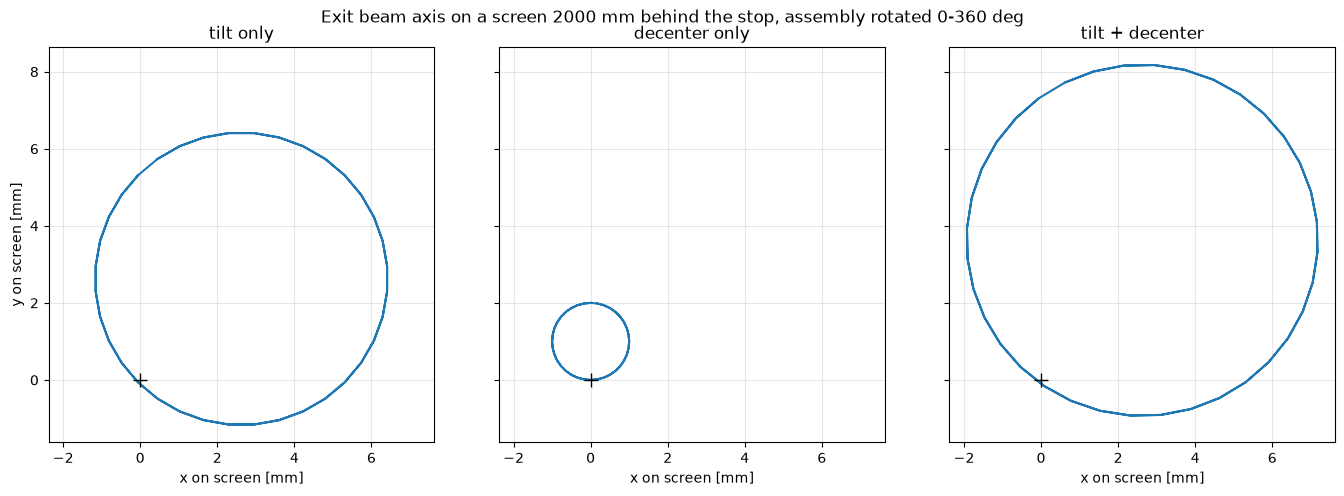

case               |r| min   |r| max         locus centre    radius    rate
tilt only           0.084     7.509 (  +2.625,  +2.625)     3.796  +2.000
decenter only       0.000     2.000 (  -0.000,  +1.000)     1.000  +2.000
tilt + decenter     0.177     9.033 (  +2.625,  +3.625)     4.558  +2.000

Each locus is a circle traced at 2 phi, so the error peaks at twice its
static value and falls to near zero twice per revolution. A decenter nulls
exactly; a tipped bearing leaves a small residual, so its circle misses the
origin - the |r| min column above, and the closest approach below. Unlike a
co-rotating error, the response does not depend on the azimuth of the tilt -
the K-mirror sweeps a lab-fixed error through every azimuth anyway.

circle fit, closest approach to the origin:
  tilt only        centre  3.712 mm, radius  3.796 mm -> misses by  0.084 mm ( 1.1% of the peak)
  decenter only    centre  1.000 mm, radius  1.000 mm -> misses by  0.000 mm ( 0.0% of the peak)
  tilt + decenter 

In [8]:
TILT = 0.1      # rigid-body tilt of the bearing axis [deg]
TILT_AZ = 45.0  # azimuth of that tilt [deg]
DECENTER = 1.0  # rigid-body decenter of the bearing axis [mm]
phis = np.arange(0, 360, 5.0)   # no duplicated endpoint -> unbiased centroid


def axis_locus(phis=phis, errors=None, pose=None):
    """Screen position of the input beam's geometric axis vs assembly rotation."""
    out = []
    for th in phis:
        o = build(phi=th, errors=errors, pose=pose, aiming=None)  # own rays
        rays = axial_rays()                        # ray 0 is the axis ray
        o.surfaces.trace(rays, skip=1)             # skip the object surface
        s = o.surfaces.surfaces[5]
        out.append((float(np.asarray(s.x)[0]), float(np.asarray(s.y)[0])))
    return np.array(out)


def azimuth_rate(d, phis=phis):
    """deg of locus azimuth per deg of assembly rotation."""
    ang = np.unwrap(np.arctan2(d[:, 1] - d[:, 1].mean(), d[:, 0] - d[:, 0].mean()))
    return np.polyfit(phis, np.degrees(ang), 1)[0]


# a perfectly placed assembly must give exactly zero pointing error
d0 = axis_locus(pose=None)
print(f"no misalignment: max |r| = {np.hypot(*d0.T).max():.2e} mm  (expect 0)\n")

cases = {"tilt only": dict(tilt=TILT, tilt_az=TILT_AZ),
         "decenter only": dict(dy=DECENTER),
         "tilt + decenter": dict(tilt=TILT, tilt_az=TILT_AZ, dy=DECENTER)}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), sharex=True, sharey=True)
for ax, (label, kw) in zip(axes, cases.items()):
    d = axis_locus(pose=kw)
    ax.plot(d[:, 0], d[:, 1], "-", lw=1.5)
    ax.plot(0, 0, "k+", ms=10)
    ax.set_title(label)
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.set_xlabel("x on screen [mm]")
axes[0].set_ylabel("y on screen [mm]")
fig.suptitle(f"Exit beam axis on a screen {SCREEN:g} mm behind the stop, "
             f"assembly rotated 0-360 deg")
plt.tight_layout()
plt.show()

print(f"{'case':16s} {'|r| min':>9} {'|r| max':>9} {'locus centre':>20} "
      f"{'radius':>9} {'rate':>7}")
for label, kw in cases.items():
    d = axis_locus(pose=kw)
    r = np.hypot(*d.T)
    cx, cy = d[:, 0].mean(), d[:, 1].mean()
    rc = np.hypot(d[:, 0] - cx, d[:, 1] - cy).mean()
    print(f"{label:16s} {r.min():8.3f} {r.max():9.3f} "
          f"({cx:+8.3f},{cy:+8.3f}) {rc:9.3f} {azimuth_rate(d):+7.3f}")

# folded distance from the assembly centre (the pivot) to the screen
ARM_CENTRE = 0.5 * X_TOTAL / np.cos(2 * a) + STOP_AFTER_M3 + SCREEN
# how close each locus comes to nulling - a decenter nulls exactly, a tipped
# bearing does not quite, so this is measured rather than asserted
print("\nEach locus is a circle traced at 2 phi, so the error peaks at twice its")
print("static value and falls to near zero twice per revolution. A decenter nulls")
print("exactly; a tipped bearing leaves a small residual, so its circle misses the")
print("origin - the |r| min column above, and the closest approach below. Unlike a")
print("co-rotating error, the response does not depend on the azimuth of the tilt -")
print("the K-mirror sweeps a lab-fixed error through every azimuth anyway.")
print("\ncircle fit, closest approach to the origin:")
for label, kw in cases.items():
    d = axis_locus(pose=kw)
    cx, cy = d[:, 0].mean(), d[:, 1].mean()          # 2 phi -> centroid is the centre
    rc = np.hypot(d[:, 0] - cx, d[:, 1] - cy).mean()
    miss = rc - np.hypot(cx, cy)
    print(f"  {label:16s} centre {np.hypot(cx, cy):6.3f} mm, radius {rc:6.3f} mm "
          f"-> misses by {miss:6.3f} mm ({100 * miss / (rc + np.hypot(cx, cy)):4.1f}% "
          f"of the peak)")
print(f"\nclosed forms, whatever the azimuth:")
print(f"  tilt      peak = 2 * arm_centre * tan(eps) = "
      f"2 * {ARM_CENTRE:.1f} * tan({TILT} deg) = "
      f"{2 * ARM_CENTRE * np.tan(np.radians(TILT)):.3f} mm")
print(f"  decenter  peak = 2 * d                     = {2 * DECENTER:.3f} mm")

### 5.1 Pointing error in angular units

The **angular pointing error** is the angle between the exit beam and the nominal optical
axis. A mirror tilted by
$\varepsilon$ deflects the beam by $2\varepsilon$ in its plane of incidence and by
$2\varepsilon\cos(\mathrm{AOI})$ out of it, so 0.1 deg of mirror tilt is 12.0 arcmin of
beam deviation no matter which of the three mirrors it is on.

Displacement on a screen is that angle times a lever arm. Because the beam pivots at
the mistilted element, not at the stop, the arm differs slightly per element, so the
angle inferred from the screen spot assuming a 2 m arm, $\arctan(r/D)$, runs a few per
cent above the true deviation. The converters below use that screen convention, which is
what a camera 2 m away actually measures; `exit_angle` returns the true deviation from
the exit ray direction if you need the distinction.

In [24]:
def mm_to_amin(v):
    return np.degrees(np.arctan2(np.asarray(v, dtype=float), SCREEN)) * 60.0


def amin_to_mm(v):
    return SCREEN * np.tan(np.radians(np.asarray(v, dtype=float) / 60.0))


def exit_angle(err=None, th=0.0, pose=None):
    """(deviation, azimuth) of the exit beam axis in deg, from ray directions.

    This is the true angular deviation, not the screen-inferred one.
    """
    o = build(phi=th, errors=err, pose=pose, aiming=None)
    rays = axial_rays()
    o.surfaces.trace(rays, skip=1)
    s = o.surfaces.surfaces[5]
    L, M, N = (float(np.asarray(v)[0]) for v in (s.L, s.M, s.N))
    return np.degrees(np.arccos(min(1.0, abs(N)))), np.degrees(np.arctan2(M, L))

## 6. Monte Carlo simulation of misalignment effects

The following section analyses the effect on pointing stability of errors both within the K-mirror (**per-mirror tilts**) and of the K-mirror in the optical path (**assembly pose**; as in section 5). For the Monte Carlo simulation, these parameters are randomly misaligned, within the following bounds:

| degree of freedom | count | tolerance |
| --- | --- | --- |
| bearing-axis tip about $x$ and about $y$ | 2 | $\pm 0.1^\circ$ |
| bearing-axis decenter $d_x$, $d_y$ | 2 | $\pm 1$ mm |
| per-mirror tilt $\varepsilon_x$, $\varepsilon_y$ (M1, M2, M3, own frames) | 6 | $\pm 0.1^\circ$ |

This results in **ten independent degrees of freedom (DOFs)**, each drawn uniformly inside its given range.

The two families of alignment errors behave differently over a revolution. The *assembly pose* is fixed in
the lab, so it sweeps at 2&phi;. The *per-mirror tilts* are locked to the mirrors, so
they spin with the assembly and sweep at 1&phi;. The total is therefore not a simple
circle: the 2&phi; and 1&phi; terms beat against each other, forming a limacon de Pascal.

random tolerance state (seed 4):
  bearing tilt      0.0886 deg at azimuth +1.5 deg
  bearing decenter  (+0.952, -0.838) mm
  M1 local ex, ey  (+0.0215, -0.0247) deg
  M2 local ex, ey  (+0.0604, -0.0651) deg
  M3 local ex, ey  (+0.0743, +0.0088) deg

  |r| =   3.479 ..  11.804 mm  (mean   7.051 mm = 12.12', rms   7.541 mm)


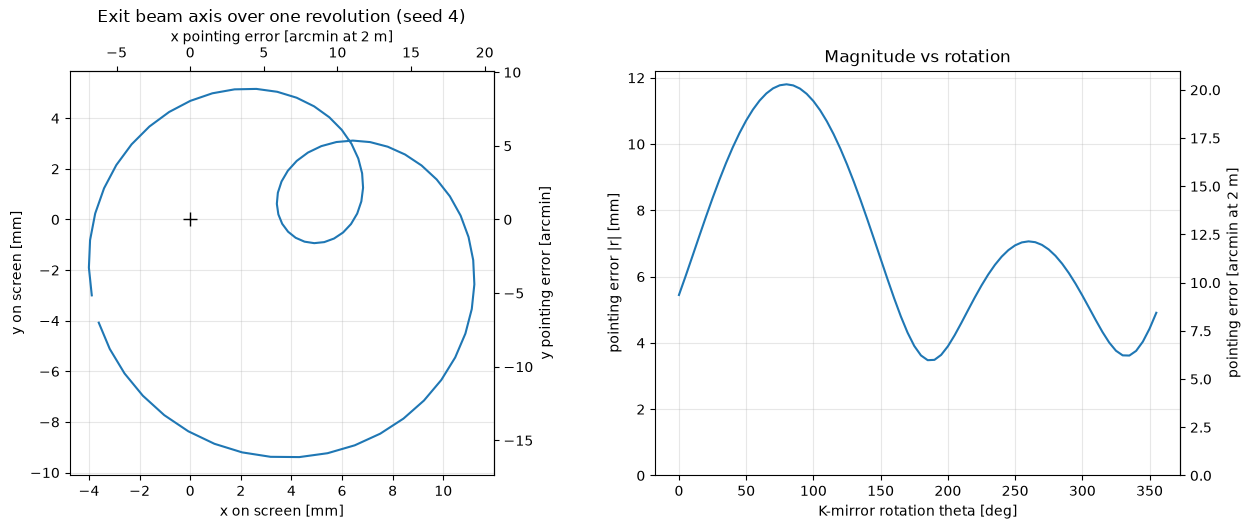


The locus is not a circle: the 2 theta bearing term and the 1 theta
per-mirror term beat, so the magnitude swings over the revolution.


In [25]:
TOL_ANG = 0.1   # tolerance on every angular DOF [deg]
TOL_DEC = 1.0   # tolerance on assembly decenter [mm]
SEED = 4


def draw_state(rng):
    """One random tolerance state; every DOF uniform inside +/- its tolerance."""
    tx, ty = rng.uniform(-TOL_ANG, TOL_ANG, 2)      # bearing-axis tip about x, y
    dx, dy = rng.uniform(-TOL_DEC, TOL_DEC, 2)      # bearing-axis decenter
    pose = dict(tilt=float(np.hypot(tx, ty)),
                tilt_az=float(np.degrees(np.arctan2(ty, tx))),
                dx=float(dx), dy=float(dy))
    errors = rng.uniform(-TOL_ANG, TOL_ANG, (3, 2))  # per-mirror local tilts
    return pose, errors


pose, errors = draw_state(np.random.default_rng(SEED))
print(f"random tolerance state (seed {SEED}):")
print(f"  bearing tilt      {pose['tilt']:.4f} deg at azimuth "
      f"{pose['tilt_az']:+.1f} deg")
print(f"  bearing decenter  ({pose['dx']:+.3f}, {pose['dy']:+.3f}) mm")
for i in range(3):
    print(f"  M{i + 1} local ex, ey  ({errors[i, 0]:+.4f}, {errors[i, 1]:+.4f}) deg")

d = axis_locus(errors=errors, pose=pose)
r = np.hypot(*d.T)
print(f"\n  |r| = {r.min():7.3f} .. {r.max():7.3f} mm  "
      f"(mean {r.mean():7.3f} mm = {mm_to_amin(r.mean()):5.2f}', "
      f"rms {np.sqrt((r ** 2).mean()):7.3f} mm)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
axes[0].plot(d[:, 0], d[:, 1], "-", lw=1.5)
axes[1].plot(phis, r, lw=1.5)

axes[0].plot(0, 0, "k+", ms=10)
axes[0].set_aspect("equal")
axes[0].set_xlabel("x on screen [mm]")
axes[0].set_ylabel("y on screen [mm]")
axes[0].set_title(f"Exit beam axis over one revolution (seed {SEED})")
axes[0].grid(alpha=0.3)
secx = axes[0].secondary_xaxis("top", functions=(mm_to_amin, amin_to_mm))
secx.set_xlabel("x pointing error [arcmin at 2 m]")
secy = axes[0].secondary_yaxis("right", functions=(mm_to_amin, amin_to_mm))
secy.set_ylabel("y pointing error [arcmin]")

axes[1].set_xlabel("K-mirror rotation phi [deg]")
axes[1].set_ylabel("pointing error |r| [mm]")
axes[1].set_title("Magnitude vs rotation")
axes[1].grid(alpha=0.3)
axes[1].set_ylim(bottom=0)
secy2 = axes[1].secondary_yaxis("right", functions=(mm_to_amin, amin_to_mm))
secy2.set_ylabel("pointing error [arcmin at 2 m]")

plt.tight_layout()
plt.show()

print("\nThe locus is not a circle: the 2 phi bearing term and the 1 phi")
print("per-mirror term beat, so the magnitude swings over the revolution.")

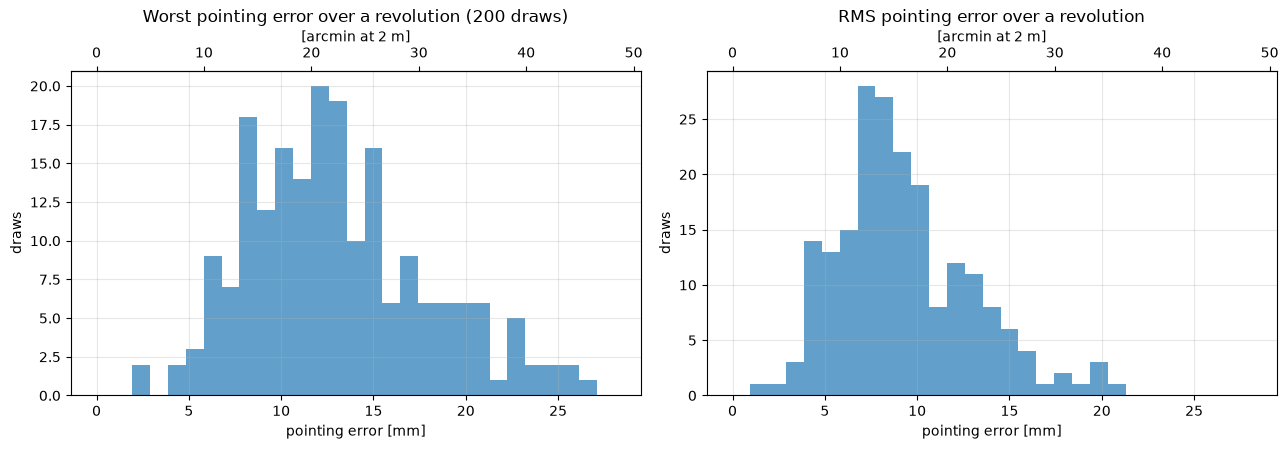

  metric           median         95th pct              max
   worst    12.31 mm 21.17'    22.46 mm 38.60'    26.73 mm 45.94'
     rms     8.65 mm 14.86'    15.83 mm 27.21'    20.63 mm 35.46'

for reference, a single 0.1 deg mirror tilt alone gives 13.2' (7.7 mm).


In [26]:
N_TRIALS = 200
th_mc = np.arange(0, 360, 10.0)     # coarser sweep; 200 x 36 traces

rng = np.random.default_rng(SEED + 1)
worst, rms_r = [], []
for _ in range(N_TRIALS):
    pose_i, err_i = draw_state(rng)
    r = np.hypot(*axis_locus(phis=th_mc, errors=err_i, pose=pose_i).T)
    worst.append(r.max())
    rms_r.append(np.sqrt((r ** 2).mean()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
bins = np.linspace(0, max(worst) * 1.05, 30)
axes[0].hist(worst, bins=bins, alpha=0.7)
axes[1].hist(rms_r, bins=bins, alpha=0.7)
axes[0].set_title(f"Worst pointing error over a revolution ({N_TRIALS} draws)")
axes[1].set_title("RMS pointing error over a revolution")
for ax in axes:
    ax.set_xlabel("pointing error [mm]")
    ax.set_ylabel("draws")
    ax.grid(alpha=0.3)
    sec = ax.secondary_xaxis("top", functions=(mm_to_amin, amin_to_mm))
    sec.set_xlabel("[arcmin at 2 m]")
plt.tight_layout()
plt.show()

print(f"{'metric':>8} {'median':>16} {'95th pct':>16} {'max':>16}")
for metric, vals in (("worst", worst), ("rms", rms_r)):
    v = np.array(vals)
    med, p95, mx = np.median(v), np.percentile(v, 95), v.max()
    print(f"{metric:>8} "
          f"{med:8.2f} mm {mm_to_amin(med):5.2f}' "
          f"{p95:8.2f} mm {mm_to_amin(p95):5.2f}' "
          f"{mx:8.2f} mm {mm_to_amin(mx):5.2f}'")

print(f"\nfor reference, a single 0.1 deg mirror tilt alone gives "
      f"{mm_to_amin(7.7):.1f}' ({7.7:.1f} mm).")

## 7. Assessing the dominant alignment error

Each of the ten degrees of freedom (section 6) is driven to its full tolerance one at a time, and the resulting pointing error is measured. **The response is linear in every DOF**, making this one-at-a-time table a
complete description, since any combined state is the linear sum of the individual responses.

Each response is reported as the RMS (root mean square error) over a revolution of the K-mirror, since the lab-fixed terms vary
with $\varphi$ while the co-rotating mirror terms do not; the RMS is what compares
fairly between them. The share of the total variance carried by each DOF follows from
those RMS values; the analysis in section 6 describes and visualizes the case where all potential alignment errors are combined.

           DOF    tolerance    rms over theta      mean       max
 bearing tip x     0.10 deg    5.310 mm  9.13'  4.780 mm  7.509 mm
 bearing tip y     0.10 deg    5.310 mm  9.13'  4.780 mm  7.509 mm
    bearing dx     1.00 mm     1.414 mm  2.43'  1.272 mm  2.000 mm
    bearing dy     1.00 mm     1.414 mm  2.43'  1.272 mm  2.000 mm
         M1 ex     0.10 deg    7.687 mm 13.21'  7.687 mm  7.687 mm
         M1 ey     0.10 deg    3.727 mm  6.41'  3.727 mm  3.727 mm
         M2 ex     0.10 deg    7.509 mm 12.91'  7.509 mm  7.509 mm
         M2 ey     0.10 deg    6.368 mm 10.95'  6.368 mm  6.368 mm
         M3 ex     0.10 deg    7.330 mm 12.60'  7.330 mm  7.330 mm
         M3 ey     0.10 deg    3.554 mm  6.11'  3.554 mm  3.554 mm

linearity check (rms |r| at 1/4, 1/2 and full tolerance):
  bearing tip y:  1.3274  2.6548  5.3097 mm   ratios 2.000, 2.000  (expect 2.000)
          M1 ex:  1.9217  3.8434  7.6868 mm   ratios 2.000, 2.000  (expect 2.000)
     bearing dy:  0.3536  0.7071  1.4142 

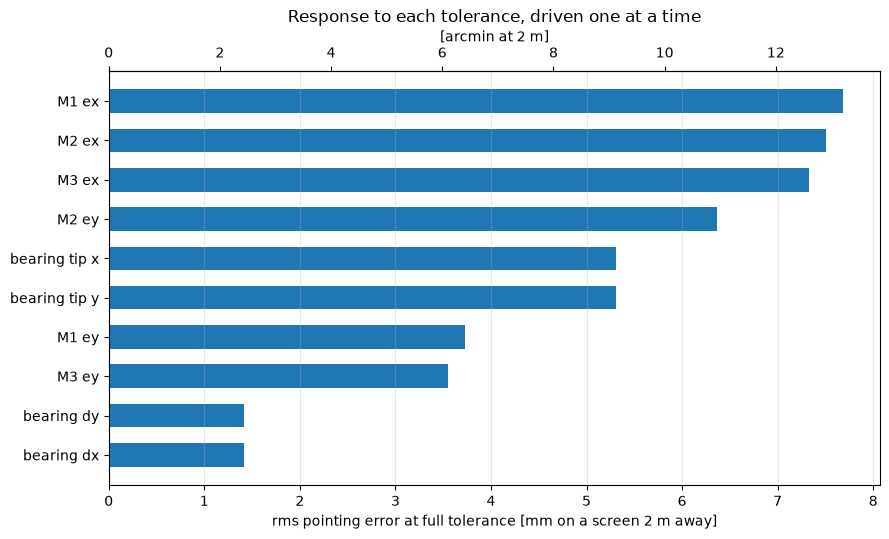


share of the total variance:
           M1 ex   7.687 mm    19.9 %   (cumulative  19.9 %)
           M2 ex   7.509 mm    19.0 %   (cumulative  38.9 %)
           M3 ex   7.330 mm    18.1 %   (cumulative  57.0 %)
           M2 ey   6.368 mm    13.7 %   (cumulative  70.7 %)
   bearing tip x   5.310 mm     9.5 %   (cumulative  80.2 %)
   bearing tip y   5.310 mm     9.5 %   (cumulative  89.7 %)
           M1 ey   3.727 mm     4.7 %   (cumulative  94.4 %)
           M3 ey   3.554 mm     4.3 %   (cumulative  98.7 %)
      bearing dy   1.414 mm     0.7 %   (cumulative  99.3 %)
      bearing dx   1.414 mm     0.7 %   (cumulative 100.0 %)


In [27]:
def dof_state(name, mag):
    """(pose, errors) with a single degree of freedom set to `mag`."""
    if name == "bearing tip x":
        return dict(tilt=mag, tilt_az=0.0), None
    if name == "bearing tip y":
        return dict(tilt=mag, tilt_az=90.0), None
    if name == "bearing dx":
        return dict(dx=mag), None
    if name == "bearing dy":
        return dict(dy=mag), None
    mirror, axis = name.split()               # e.g. "M2 ey"
    errors = np.zeros((3, 2))
    errors[int(mirror[1]) - 1, "xy".index(axis[1])] = mag
    return None, errors


DOFS = [("bearing tip x", TOL_ANG, "deg"), ("bearing tip y", TOL_ANG, "deg"),
        ("bearing dx", TOL_DEC, "mm"), ("bearing dy", TOL_DEC, "mm")]
DOFS += [(f"M{i} e{ax}", TOL_ANG, "deg") for i in (1, 2, 3) for ax in "xy"]

# the RMS over a revolution is the quantity that adds in quadrature, so it is
# what the budget below is built from; mean and max are shown for context
resp = {}
print(f"{'DOF':>14} {'tolerance':>12} {'rms over phi':>17} {'mean':>9} "
      f"{'max':>9}")
for name, tol, unit in DOFS:
    pose, errors = dof_state(name, tol)
    r = np.hypot(*axis_locus(errors=errors, pose=pose).T)
    resp[name] = np.sqrt((r ** 2).mean())
    print(f"{name:>14} {tol:8.2f} {unit:3s} {resp[name]:8.3f} mm "
          f"{mm_to_amin(resp[name]):5.2f}' {r.mean():6.3f} mm {r.max():6.3f} mm")

# --- the response is linear, so one coefficient per DOF says everything ---
print("\nlinearity check (rms |r| at 1/4, 1/2 and full tolerance):")
for name in ("bearing tip y", "M1 ex", "bearing dy"):
    tol = TOL_DEC if name.startswith("bearing d") else TOL_ANG
    v = []
    for f in (0.25, 0.5, 1.0):
        pose, errors = dof_state(name, f * tol)
        r = np.hypot(*axis_locus(errors=errors, pose=pose).T)
        v.append(np.sqrt((r ** 2).mean()))
    print(f"  {name:>13}: {v[0]:7.4f} {v[1]:7.4f} {v[2]:7.4f} mm   "
          f"ratios {v[1] / v[0]:.3f}, {v[2] / v[1]:.3f}  (expect 2.000)")

# --- ranked contributions -------------------------------------------------
order = sorted(resp, key=lambda k: -resp[k])
y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(y, [resp[k] for k in order], 0.6)
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.invert_yaxis()
ax.set_xlabel("rms pointing error at full tolerance [mm on a screen 2 m away]")
ax.set_title("Response to each tolerance, driven one at a time")
ax.grid(alpha=0.3, axis="x")
sec = ax.secondary_xaxis("top", functions=(mm_to_amin, amin_to_mm))
sec.set_xlabel("[arcmin at 2 m]")
plt.tight_layout()
plt.show()

total_var = sum(v ** 2 for v in resp.values())
print("\nshare of the total variance:")
cum = 0.0
for name in order:
    share = 100 * resp[name] ** 2 / total_var
    cum += share
    print(f"  {name:>14} {resp[name]:7.3f} mm   {share:5.1f} %   "
          f"(cumulative {cum:5.1f} %)")

### 7.1 Can the M2 mirror be used to compensate for other alignment errors?

In our 3D-printed K-mirror design, two adjustments screws can be used to tilt the M2 mirror by
$(\varepsilon_x, \varepsilon_y)$. Can these degrees of freedom be used to compensate for other alignment errors?

Since the response is linear in every degree of freedom (section 7), the corrected locus can be computed as

$$\mathbf{r}(\varphi) = \mathbf{r}_0(\varphi)
  + \varepsilon_x \mathbf{J}_x(\varphi) + \varepsilon_y \mathbf{J}_y(\varphi)$$

with $\mathbf{r}_0$ the locus with M2 in the default tilt angle and $\mathbf{J}$ the M2 response per degree.
Minimising the RMS of $|\mathbf{r}|$ over a revolution is then an ordinary two-parameter
least-squares problem. This does not require an iterative optimiser, and the solution is the global
optimum.

Since M2 spins with the assembly, its response is a $1\varphi$ term. It can therefore only address the $1\varphi$ part of
the error (*per-mirror tilts*) and cannot compensate for the $2\varphi$ term, which
no static tilt of any mirror can remove.

seed 4: M2 correction ex = +0.0945, ey = -0.0096 deg (tolerance 0.1 deg)
  as drawn           rms   7.541 mm   |r|  3.479 ..  11.804 mm
  M2 zeroed          rms   9.409 mm   |r|  0.581 ..  15.800 mm
  M2 optimised       rms   6.145 mm   |r|  0.071 ..   8.691 mm
  bearing pose only  rms   6.145 mm   |r|  0.073 ..   8.690 mm


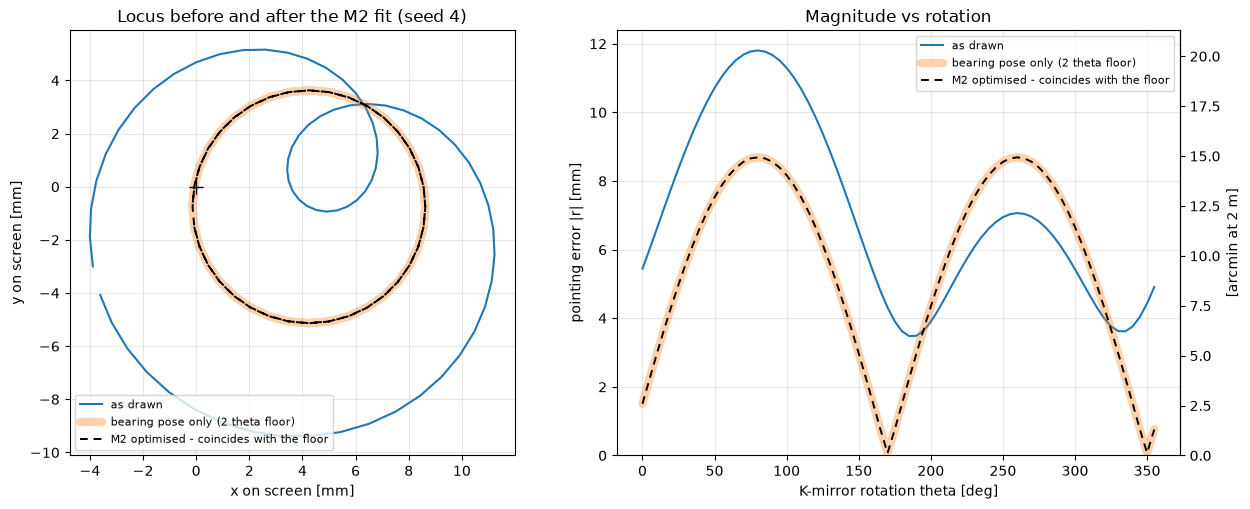


30 random draws, M2 (ex, ey) fitted to each:
                           median   95th pct        max
rms as drawn [mm]           8.856     19.474     19.903
rms corrected [mm]          4.217      6.362      7.972
2 theta floor [mm]          4.217      6.362      7.972
M2 tilt needed [deg]        0.083      0.158      0.169

median improvement factor 2.21x; corrected result sits 1.00x the 2 theta floor
draws needing more than the 0.1 deg tolerance on M2: 37%


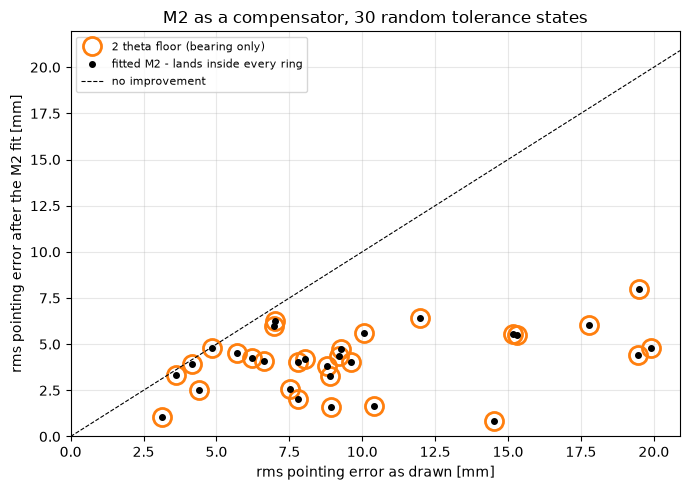

In [28]:
def m2_correction(pose, errors, ths=phis):
    """Least-squares M2 (ex, ey) [deg] minimising rms |r| over a revolution.

    Linear in the tilts, so this is a 2-parameter least-squares fit, not a search.
    """
    e0 = np.array(errors, dtype=float).copy()
    e0[1] = 0.0                                    # M2 set aside
    r0 = axis_locus(phis=ths, errors=e0, pose=pose)
    cols = []
    for k in (0, 1):                               # M2 response per degree
        e = np.zeros((3, 2))
        e[1, k] = TOL_ANG
        cols.append(axis_locus(phis=ths, errors=e).ravel() / TOL_ANG)
    c, *_ = np.linalg.lstsq(np.stack(cols, axis=1), -r0.ravel(), rcond=None)
    return c, e0


def rms(d):
    return float(np.sqrt((d ** 2).sum(axis=1).mean()))


# --- one draw, in detail --------------------------------------------------
pose_c, err_c = draw_state(np.random.default_rng(SEED))
c, e0 = m2_correction(pose_c, err_c)
e_fix = e0.copy()
e_fix[1] = c

before = axis_locus(errors=err_c, pose=pose_c)
after = axis_locus(errors=e_fix, pose=pose_c)
nom2 = axis_locus(errors=e0, pose=pose_c)          # M2 perfect, uncorrected
only_pose = axis_locus(pose=pose_c)                # the 2 phi floor

print(f"seed {SEED}: M2 correction ex = {c[0]:+.4f}, ey = {c[1]:+.4f} deg "
      f"(tolerance {TOL_ANG} deg)")
for name, d in (("as drawn", before), ("M2 zeroed", nom2),
                ("M2 optimised", after), ("bearing pose only", only_pose)):
    r = np.hypot(*d.T)
    print(f"  {name:18s} rms {rms(d):7.3f} mm   |r| {r.min():6.3f} .. "
          f"{r.max():7.3f} mm")

# "M2 optimised" lands on "bearing pose only" to three digits, so draw the
# floor as a broad pale band and the fit as a thin dashed line on top of it -
# seeing the dashes sit inside the band *is* the result
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
styles = (("as drawn", before, dict(lw=1.5, color="tab:blue")),
          ("bearing pose only (2 phi floor)", only_pose,
           dict(lw=6, color="tab:orange", alpha=0.35, solid_capstyle="round")),
          ("M2 optimised - coincides with the floor", after,
           dict(lw=1.4, color="k", ls=(0, (4, 3)))))
for name, d, kw in styles:
    axes[0].plot(d[:, 0], d[:, 1], label=name, **kw)
    axes[1].plot(phis, np.hypot(*d.T), label=name, **kw)
axes[0].plot(0, 0, "k+", ms=10)
axes[0].set_aspect("equal")
axes[0].set_xlabel("x on screen [mm]")
axes[0].set_ylabel("y on screen [mm]")
axes[0].set_title(f"Locus before and after the M2 fit (seed {SEED})")
axes[1].set_xlabel("K-mirror rotation phi [deg]")
axes[1].set_ylabel("pointing error |r| [mm]")
axes[1].set_title("Magnitude vs rotation")
axes[1].set_ylim(bottom=0)
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
sec = axes[1].secondary_yaxis("right", functions=(mm_to_amin, amin_to_mm))
sec.set_ylabel("[arcmin at 2 m]")
plt.tight_layout()
plt.show()

# --- over an ensemble of draws -------------------------------------------
N_FIT = 30
th_fit = np.arange(0, 360, 15.0)                   # coarser sweep for the loop
rng = np.random.default_rng(SEED + 2)
rows = []
for _ in range(N_FIT):
    p_i, e_i = draw_state(rng)
    c_i, e0_i = m2_correction(p_i, e_i, ths=th_fit)
    e_fix_i = e0_i.copy()
    e_fix_i[1] = c_i
    rows.append((rms(axis_locus(phis=th_fit, errors=e_i, pose=p_i)),
                 rms(axis_locus(phis=th_fit, errors=e_fix_i, pose=p_i)),
                 rms(axis_locus(phis=th_fit, pose=p_i)),
                 float(np.hypot(*c_i))))
before_r, after_r, floor_r, mag = (np.array(v) for v in zip(*rows))

print(f"\n{N_FIT} random draws, M2 (ex, ey) fitted to each:")
print(f"{'':22s} {'median':>10} {'95th pct':>10} {'max':>10}")
for name, v in (("rms as drawn [mm]", before_r), ("rms corrected [mm]", after_r),
                ("2 phi floor [mm]", floor_r),
                ("M2 tilt needed [deg]", mag)):
    print(f"{name:22s} {np.median(v):10.3f} {np.percentile(v, 95):10.3f} "
          f"{v.max():10.3f}")
print(f"\nmedian improvement factor {np.median(before_r / after_r):.2f}x; "
      f"corrected result sits {np.median(after_r / floor_r):.2f}x the 2 phi floor")
print(f"draws needing more than the {TOL_ANG} deg tolerance on M2: "
      f"{100 * np.mean(mag > TOL_ANG):.0f}%")

fig, ax = plt.subplots(figsize=(7, 5))
# every fitted point falls on its own floor point, so plot the floor as a large
# open ring and the fit as a small dot centred in it
ax.plot(before_r, floor_r, "o", ms=13, mfc="none", mec="tab:orange", mew=2,
        ls="none", label="2 phi floor (bearing only)")
ax.plot(before_r, after_r, "o", ms=4, color="k", ls="none",
        label="fitted M2 - lands inside every ring")
lim = [0, before_r.max() * 1.05]
ax.plot(lim, lim, "k--", lw=0.8, label="no improvement")
ax.set_xlim(lim)
ax.set_ylim(bottom=0)
ax.set_xlabel("rms pointing error as drawn [mm]")
ax.set_ylabel("rms pointing error after the M2 fit [mm]")
ax.set_title(f"M2 as a compensator, {N_FIT} random tolerance states")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Clipping over the scan

In this section, the clipping of the laser beam is analyzed when it is scanned by the scan mirrors. Note that the K-mirror is perfectly aligned here by itself and within the optical beam path. Essentially, we analyze to which extent the beam gets past the three flat mirrors over the scan range.

Without loss of generality, the scan is defined in the $YZ$ convention: the field angle is $(0, u)$, so the
beam tilts in the $y$-$z$ meridional plane and `Hy` drives it. At $\varphi = 0$ the K-mirror also
folds in $YZ$, so the scan starts out in the fold plane, which is the worst orientation.

The on-axis limit is $D_{max} = L\sin\alpha = 24.97$ mm. A field angle uses this margin:
the chief ray at $u$ walks $\mathrm{arm}\times\tan u$ across M1, and because M1 is seen at
$61^\circ$, this walk is magnified by $1/\sin\alpha = 2.06$ when it points along the fold.
The available in-plane margin is only $(L - D/\sin\alpha)/2$, so the walk runs out quickly.
Whether the beam is clipped depends on the assembly rotation $\varphi$, so the scan and the
rotation are swept together.

Optiland derives the traced field from `(Hx, Hy)`
times the maximum *radial* field, so the tuples given to `fields.add()` only set the scale, they do not select which field is traced. `Hy=+1` and `Hy=-1` are genuinely different
geometries here (M2 sits on one side only), and they differ by several percentage points
at a given $\varphi$; their curves are related by a $180^\circ$ shift in $\varphi$, which is
why the sweep runs over a full turn.

The stop is opened to the beam so that **only the mirrors can clip the beam**. A stop smaller
than the beam would cut it at every field, which is a question about pupil size rather than about
K-mirror clipping.

D_max = L*sin(alpha)     = 24.97 mm
beam                     = 22.00 mm  (radial margin 1.48 mm on axis)
chief-ray walk at M1     = 4.30 mm (arm 202.1 mm), 8.88 mm along the mirror
chief-ray walk at M3     = 2.13 mm (arm 100 mm)
in-fold-plane margin     = (L - 22/sin(alpha))/2 = 3.06 mm
perpendicular margin     = (L - 22)/2 = 14.75 mm


C:\Users\Nikita\AppData\Local\Temp\ipykernel_22464\4240564874.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


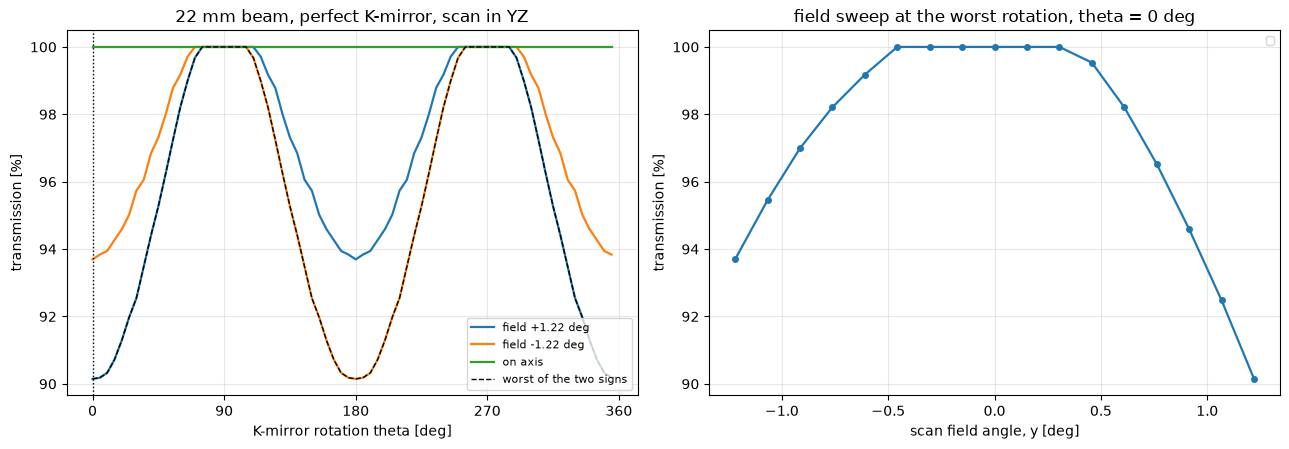


worst transmission 90.15% at theta = 0 deg, field +1.22 deg
on-axis transmission over all theta: 100.00%
the two signs differ by up to 3.65 percentage points - tracing only one of them understates the loss
clipping-free rotations: theta = 75..285 deg

incremental loss per surface at field +1.22 deg:
  theta       M1       M2       M3     stop         T
    0.0    9.85%    0.00%    0.00%    0.00%    90.15%
   30.0    7.45%    0.00%    0.00%    0.00%    92.55%
   60.0    1.79%    0.00%    0.00%    0.00%    98.21%
   90.0    0.00%    0.00%    0.00%    0.00%   100.00%
  120.0    0.82%    0.00%    0.00%    0.00%    99.18%
  150.0    4.26%    0.00%    0.00%    0.00%    95.74%


In [29]:
BEAM = EPD      # beam diameter for this section [mm]; follows the global EPD
SCAN = 1.22     # scan half-angle [deg], from the system specification -
                # entered by hand, not derived anywhere in this notebook

print(f"D_max = L*sin(alpha)     = {D_MAX:.2f} mm")
print(f"beam                     = {BEAM:.2f} mm  "
      f"(radial margin {(D_MAX - BEAM) / 2:.2f} mm on axis)")
print(f"chief-ray walk at M1     = {ARM_M1_TO_STOP * np.tan(np.radians(SCAN)):.2f} mm "
      f"(arm {ARM_M1_TO_STOP:.1f} mm), "
      f"{ARM_M1_TO_STOP * np.tan(np.radians(SCAN)) / np.sin(a):.2f} mm along the mirror")
print(f"chief-ray walk at M3     = "
      f"{STOP_AFTER_M3 * np.tan(np.radians(SCAN)):.2f} mm (arm {STOP_AFTER_M3:.0f} mm)")
print(f"in-fold-plane margin     = (L - {BEAM:g}/sin(alpha))/2 = "
      f"{(L - BEAM / np.sin(a)) / 2:.2f} mm")
print(f"perpendicular margin     = (L - {BEAM:g})/2 = {(L - BEAM) / 2:.2f} mm")


def trace_field(phi, hy, epd=BEAM, n=30):
    """Trace a filled hexapolar bundle at NORMALISED meridional field `hy`.

    The scan is in the YZ plane, so the field is (0, u) and `Hy` drives it.
    Optiland computes the traced field as (Hx, Hy) times the maximum *radial*
    field of the group, so the field list here only fixes max_field = SCAN;
    passing Hy=1 with a list of ((0,0), (0,-SCAN)) would trace +SCAN, not
    -SCAN. Driving `hy` directly is the only way to control the sign.

    Args:
        phi: assembly rotation [deg].
        hy: normalised meridional field coordinate; +/-1 are the scan extremes.
        epd: beam diameter [mm], which also sets the stop radius.
        n: hexapolar ring count.

    Returns:
        Optic: traced system.
    """
    o = build(phi=phi, fields=((0.0, 0.0), (0.0, SCAN)), epd=epd)
    o.trace(Hx=0.0, Hy=hy, wavelength=WAVELENGTH, num_rays=n,
            distribution="hexapolar")
    return o


def incremental_loss(o):
    """Percent of the bundle first blocked at each surface, and what survives.

    The stop column is structurally zero while the stop radius follows the beam
    and ray aiming is on, since the aimed bundle fills the stop exactly. It is
    kept as a guard: it stops being zero the moment either of those changes.
    """
    prev = np.asarray(o.surfaces.surfaces[1].intensity) > -1   # all True
    out = {}
    for idx in (1, 2, 3, 4):
        ok = np.asarray(o.surfaces.surfaces[idx].intensity) > 0
        out[idx] = 100 * np.mean(prev & ~ok)
        prev = prev & ok
    return out, 100 * np.mean(prev)


def local_xy(o, idx):
    """Ray intersections on surface `idx`, expressed in that mirror's own frame."""
    surf = o.surfaces.surfaces[idx]
    t, R = surf.geometry.cs.get_effective_transform()
    p = np.stack([np.asarray(surf.x), np.asarray(surf.y), np.asarray(surf.z)])
    loc = np.asarray(R).T @ (p - np.asarray(t).reshape(3, 1))
    return loc[0], loc[1], np.asarray(surf.intensity)


# a full turn, because the two field signs are related by a 180 deg shift
th_scan = np.arange(0, 360, 5.0)
curves = {h: np.array([incremental_loss(trace_field(t, h))[1] for t in th_scan])
          for h in (-1.0, 0.0, 1.0)}

envelope = np.minimum(curves[1.0], curves[-1.0])
worst_i = envelope.argmin()
TH_WORST = th_scan[worst_i]
H_WORST = 1.0 if curves[1.0][worst_i] <= curves[-1.0][worst_i] else -1.0

hs = np.linspace(-1.0, 1.0, 17)
by_field = np.array([incremental_loss(trace_field(TH_WORST, h))[1] for h in hs])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for h, lbl in ((1.0, f"field +{SCAN} deg"), (-1.0, f"field -{SCAN} deg"),
               (0.0, "on axis")):
    axes[0].plot(th_scan, curves[h], lw=1.6, label=lbl)
axes[0].plot(th_scan, envelope, "k--", lw=1, label="worst of the two signs")
axes[0].axvline(TH_WORST, color="k", ls=":", lw=1)
axes[0].set_xlabel("K-mirror rotation phi [deg]")
axes[0].set_ylabel("transmission [%]")
axes[0].set_title(f"{BEAM:g} mm beam, perfect K-mirror, scan in YZ")
axes[0].set_xticks(range(0, 361, 90))
axes[1].plot(hs * SCAN, by_field, "-o", ms=4, lw=1.6)
axes[1].set_xlabel("scan field angle, y [deg]")
axes[1].set_ylabel("transmission [%]")
axes[1].set_title(f"field sweep at the worst rotation, phi = {TH_WORST:g} deg")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nworst transmission {envelope[worst_i]:.2f}% at phi = {TH_WORST:g} deg, "
      f"field {H_WORST * SCAN:+.2f} deg")
print(f"on-axis transmission over all phi: {curves[0.0].min():.2f}%")
print(f"the two signs differ by up to "
      f"{np.abs(curves[1.0] - curves[-1.0]).max():.2f} percentage points - "
      f"tracing only one of them understates the loss")
clean = th_scan[envelope > 99.999]
if len(clean):
    print(f"clipping-free rotations: phi = {clean.min():g}..{clean.max():g} deg")

print(f"\nincremental loss per surface at field {H_WORST * SCAN:+.2f} deg:")
print(f"{'phi':>7} {'M1':>8} {'M2':>8} {'M3':>8} {'stop':>8} {'T':>9}")
for t in (TH_WORST, 30.0, 60.0, 90.0, 120.0, 150.0):
    loss, T = incremental_loss(trace_field(t, H_WORST))
    print(f"{t:7.1f} {loss[1]:7.2f}% {loss[2]:7.2f}% {loss[3]:7.2f}% "
          f"{loss[4]:7.2f}% {T:8.2f}%")

### 8.1 Ray diagrams at $\varphi = 0$ and $\varphi = 90^\circ$

2D projections are rendered with `draw()`. The K-mirror rotates such that it lies in the $YZ$ plane at
$\varphi = 0$, and in the $XZ$ plane for $\varphi = 90^\circ$. Both views are shown.

The scan is again, without loss of generality, restricted to the $YZ$ plane. Therefore:

- at $\varphi = 0$ the scan lies inside the K-mirror fold plane.
- at $\varphi = 90^\circ$ the scan is perpendicular to the fold.

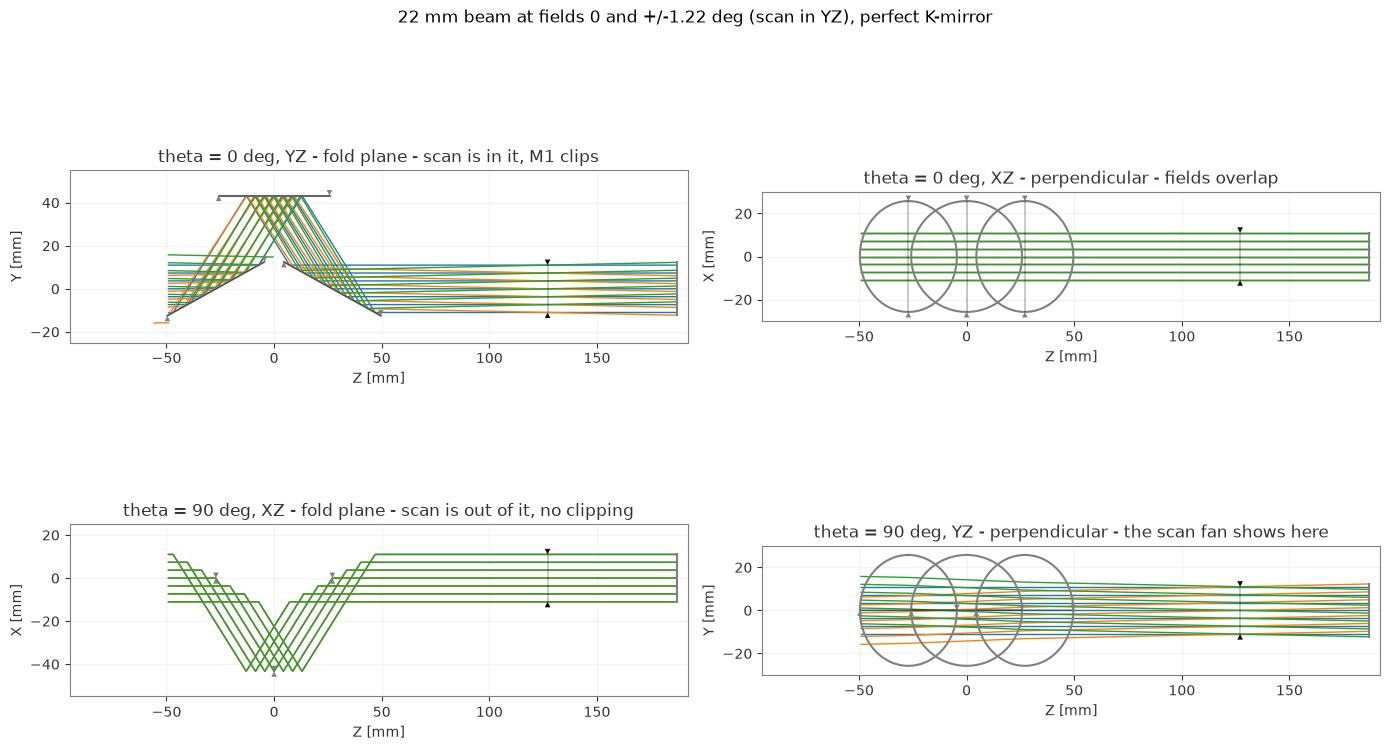

walk magnification in the fold plane = 1/sin(alpha) = 2.06


In [30]:
# M2 is at +H in y when phi = 0, and at -H in x when phi = 90 deg, so each
# panel needs its own framing; (phi, projection, cross-axis limits, note)
PANELS = [(0.0, "YZ", (-25, 55), "fold plane - scan is in it, M1 clips"),
          (0.0, "XZ", (-30, 30), "perpendicular - fields overlap"),
          (90.0, "XZ", (-55, 25), "fold plane - scan is out of it, no clipping"),
          (90.0, "YZ", (-30, 30), "perpendicular - the scan fan shows here")]

fig, axes = plt.subplots(2, 2, figsize=(14, 8.5))
for ax, (th, proj, lim, note) in zip(axes.ravel(), PANELS):
    o = build(phi=th, fields=((0.0, 0.0), (0.0, SCAN), (0.0, -SCAN)),
              screen=60.0, epd=BEAM)
    o.draw(num_rays=7, projection=proj, ax=ax, show_apertures=True,
           title=f"phi = {th:g} deg, {proj} - {note}")
    ax.set_ylim(*lim)
    ax.set_xlim(-95, Z_STOP + 65)
    ax.set_aspect("equal")
fig.suptitle(f"{BEAM:g} mm beam at fields 0 and +/-{SCAN} deg (scan in YZ), "
             f"perfect K-mirror")
plt.tight_layout()
plt.show()

print(f"walk magnification in the fold plane = 1/sin(alpha) = {1 / np.sin(a):.2f}")

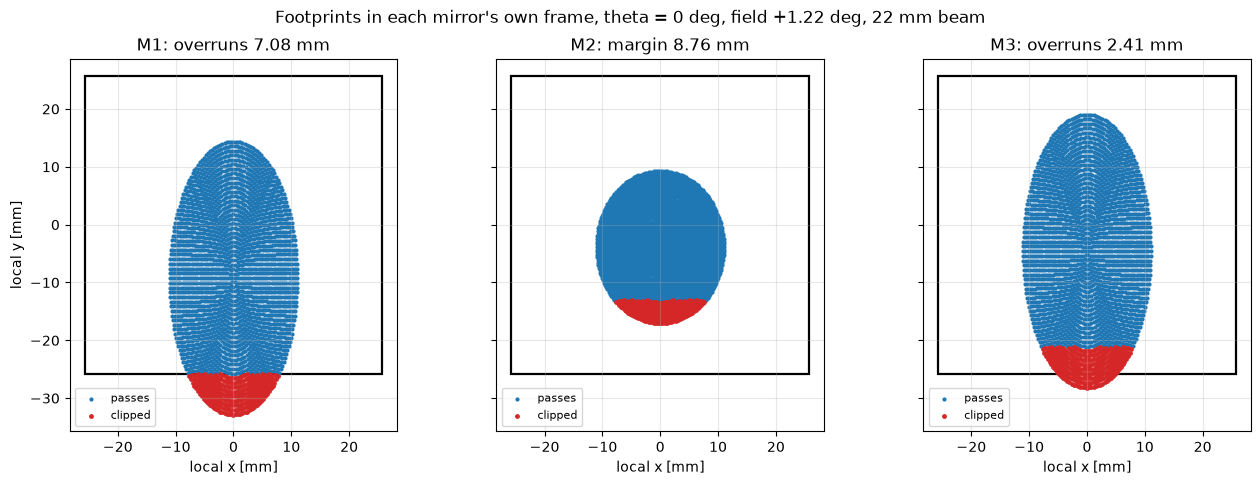

 mirror       footprint y extent   half-size    overrun
     M1     -32.83 ..  +14.36 mm     25.75 mm     +7.08 mm
     M2     -16.99 ..   +9.30 mm     25.75 mm     -8.76 mm
     M3     -28.16 ..  +19.03 mm     25.75 mm     +2.41 mm

analytic estimate: d <= L*sin(alpha) - 2*walk = 16.36 mm (optimistic - see below)
largest beam that passes 100% over the full scan, all theta, both signs:
   13.0 mm -> 100.00%
   14.0 mm -> 100.00%
   15.0 mm -> 100.00%
   16.0 mm ->  99.13%   <- clips
   17.0 mm ->  97.70%   <- clips
   18.0 mm ->  96.19%   <- clips
   19.0 mm ->  94.61%   <- clips
   20.0 mm ->  92.78%   <- clips
   21.0 mm ->  91.20%   <- clips
   22.0 mm ->  90.09%   <- clips
   23.0 mm ->  88.58%   <- clips


In [31]:
# --- footprints at the worst case ----------------------------------------
o = trace_field(TH_WORST, H_WORST, n=30)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.8), sharex=True, sharey=True)
for ax, (idx, name) in zip(axes, [(1, "M1"), (2, "M2"), (3, "M3")]):
    lx, ly, ii = local_xy(o, idx)
    ok = ii > 0
    ax.add_patch(plt.Rectangle((-L / 2, -L / 2), L, L, fill=False, ec="k", lw=1.6))
    ax.scatter(lx[ok], ly[ok], s=4, c="tab:blue", label="passes")
    if (~ok).any():
        ax.scatter(lx[~ok], ly[~ok], s=6, c="tab:red", label="clipped")
    over = max(np.abs(lx).max(), np.abs(ly).max()) - L / 2
    ax.set_title(f"{name}: {'overruns' if over > 0 else 'margin'} "
                 f"{abs(over):.2f} mm")
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.set_xlabel("local x [mm]")
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel("local y [mm]")
fig.suptitle(f"Footprints in each mirror's own frame, phi = {TH_WORST:g} deg, "
             f"field {H_WORST * SCAN:+.2f} deg, {BEAM:g} mm beam")
plt.tight_layout()
plt.show()

print(f"{'mirror':>7} {'footprint y extent':>24} {'half-size':>11} {'overrun':>10}")
for idx, name in ((1, "M1"), (2, "M2"), (3, "M3")):
    lx, ly, _ = local_xy(o, idx)          # all rays, including the clipped ones
    over = max(ly.max(), -ly.min()) - L / 2
    print(f"{name:>7} {ly.min():+10.2f} .. {ly.max():+7.2f} mm {L / 2:9.2f} mm "
          f"{over:+9.2f} mm")

# --- how large a beam clears the whole scan ------------------------------
walk = ARM_M1_TO_STOP * np.tan(np.radians(SCAN))
print(f"\nanalytic estimate: d <= L*sin(alpha) - 2*walk = "
      f"{L * np.sin(a) - 2 * walk:.2f} mm (optimistic - see below)")
print("largest beam that passes 100% over the full scan, all phi, both signs:")
for d in np.arange(13.0, 23.01, 1.0):
    tmin = 100.0
    for t in np.arange(0, 360, 15.0):
        for h in (-1.0, 1.0):
            tmin = min(tmin, incremental_loss(trace_field(t, h, epd=d, n=20))[1])
    print(f"  {d:5.1f} mm -> {tmin:6.2f}%" + ("   <- clips" if tmin < 99.999 else ""))

### 8.2 Where to put the stop

Section 8 fixed the stop (back focal plane of objective) 100 mm behind M3. The sweep below drives this parameter from 0 to 200 mm at the most sensitive case of
$\varphi = 0$ with the field at $+1.22^\circ$. Therefore, the curve is the worst transmission over
a full revolution rather than a typical one.

*Technical detail: The stop cannot be moved through `build`'s arguments, so the cell rebinds the module-level
`Z_STOP` around the sweep and restores it in a `finally`. Without that, an interrupted
sweep would leave every later cell tracing a stop that is not where section 1 says it is.*


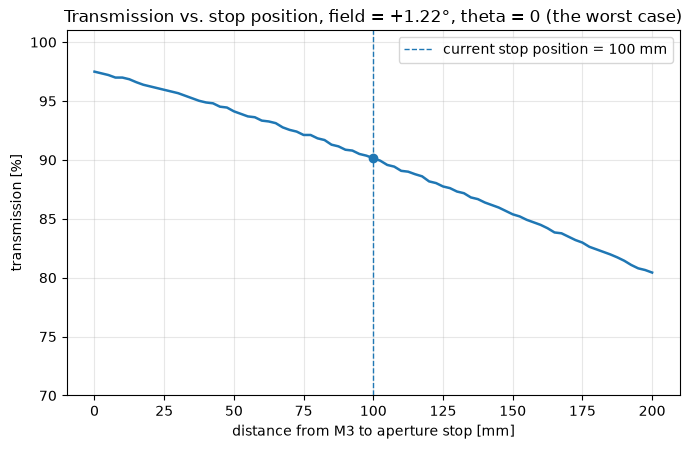

stop at M3            ->  97.49 %
stop 100 mm behind M3   ->  90.15 %   (section 8's worst case over theta prints the same number)
stop 200 mm behind M3 ->  80.44 %

Z_STOP restored to 127.05 mm (nominal 127.05 mm), arm 202.10 mm


In [32]:
# Transmission at the +SCAN field as a function of the M3-to-stop distance.

STOP_DISTANCES = np.linspace(0.0, 200.0, 81)   # STOP_AFTER_M3 [mm]
EPD_SCAN = BEAM
N_RAYS = 30


def set_stop_position(stop_after_m3):
    """Move the stop to `stop_after_m3` behind M3.

    `build` reads the module-level Z_STOP when it places surface 4, so the stop
    is moved by rebinding it. ARM_M1_TO_STOP is a printed diagnostic that
    nothing traces with, but it is kept in step so it cannot go stale while the
    sweep runs.
    """
    global Z_STOP, ARM_M1_TO_STOP
    Z_STOP = Z3 + stop_after_m3
    ARM_M1_TO_STOP = X_TOTAL / np.cos(2 * a) + stop_after_m3


def trace_field_vs_stop(stop_after_m3, epd=EPD_SCAN, n=N_RAYS):
    """Trace the +SCAN field with the stop `stop_after_m3` behind M3."""
    set_stop_position(stop_after_m3)
    o = build(
        phi=0.0,
        fields=((0.0, 0.0), (0.0, SCAN)),
        epd=epd,
    )
    o.trace(
        Hx=0.0,
        Hy=1.0,
        wavelength=WAVELENGTH,
        num_rays=n,
        distribution="hexapolar",
    )
    return o


# The restore has to happen even if the sweep is interrupted: leaving Z_STOP at
# a swept value would have every later cell tracing a stop that is not where
# section 1 says it is, with nothing to show that it moved.
try:
    T_vs_stop = np.array([incremental_loss(trace_field_vs_stop(d))[1]
                          for d in STOP_DISTANCES])
finally:
    set_stop_position(STOP_AFTER_M3)

T_here = float(np.interp(STOP_AFTER_M3, STOP_DISTANCES, T_vs_stop))


# Plot
fig, ax = plt.subplots(figsize=(7.0, 4.6))

ax.plot(
    STOP_DISTANCES,
    T_vs_stop,
    lw=1.8,
)

ax.axvline(
    STOP_AFTER_M3,
    ls="--",
    lw=1.0,
    label=f"current stop position = {STOP_AFTER_M3:g} mm",
)

ax.scatter(
    [STOP_AFTER_M3],
    [T_here],
    zorder=3,
)

ax.set_xlabel("distance from M3 to aperture stop [mm]")
ax.set_ylabel("transmission [%]")
ax.set_title(
    f"Transmission vs. stop position, "
    f"field = +{SCAN:g}°, phi = 0 (the worst case)"
)

ax.set_ylim(70, 101)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

fig.savefig(
    "transmission_vs_stop_position.pdf",
    bbox_inches="tight",
)

print(f"stop at M3            -> {T_vs_stop[0]:6.2f} %")
print(f"stop {STOP_AFTER_M3:g} mm behind M3   -> {T_here:6.2f} %   "
      f"(section 8's worst case over phi prints the same number)")
print(f"stop 200 mm behind M3 -> {T_vs_stop[-1]:6.2f} %")
print(f"\nZ_STOP restored to {Z_STOP:.2f} mm "
      f"(nominal {Z3 + STOP_AFTER_M3:.2f} mm), arm {ARM_M1_TO_STOP:.2f} mm")


# 9. Summary of results

## 9.1 Alignment errors and pointing stability

- **M2 alone aligns the K-mirror to its own bearing.** Fitting M2's two tilts cancels the
  whole $1\varphi$ wobble. The three mirrors
  do not need to be individually accurate if they can be adjusted via M2.
- **What is the necessary range for M2?** A median $0.083^\circ$ of M2 tilt, over the $\pm0.1^\circ$ band on
  37% of draws. The adjuster needs about twice the tolerance in range.
- **What M2 cannot do.** M2 spins with the assembly, so its response cannot reach the lab-fixed $2\varphi$ bearing error.
- **After alignment the bearing is the whole problem.** Four degrees of freedom remain: the
  two tips carry 93% of the residual variance, the two decenters 7%.
- **Out-of-plane mirror tilts are cheaper by $\cos(\mathrm{AOI})$.** $\varepsilon_y$ costs
  0.485 of $\varepsilon_x$ on M1 and M3 (AOI $61^\circ$) and 0.85 on M2 (AOI $32^\circ$) -
  the single-mirror law of section 5.1, which is also why M2 $\varepsilon_y$ is the fourth
  largest term in the table.
- **Decenter is nearly free.** 1.4% of the variance before adjustment, 7% of what
  remains after. $\pm1$ mm could be relaxed to $\pm3$ mm; tightening it buys nothing.

## 9.2 Beam clipping during scanning

- **Beam clipping is moderate** for the investigated system and the applied scan angles.
- **Scanning within the K-mirror fold** maximizes beam clipping. For scanning orthogonal to the fold, beam clipping is minimized.
- **The distance between M3 mirror and objective** should be minimized to reduce beam clipping (section 8.2), but is physically limited by the addition of the dichroic mirror and the necessity to move the objective in z-direction.
- **Larger scan angles** may lead, depending on the microscope's configuration and beam sizes, to substantial beam clipping.


## 9.3 Assumptions and caveats

- **Design values** $\alpha = 29^\circ$, $L = 51.5$, $T = 6.25$, $X_{buffer} = 3$ mm.
- **The input beam is the reference axis**, perfectly on-axis by design, assuming a perfectly aligned two-photon microscopy. Every
  misalignment is due to the K-mirror.
- **Pointing and clipping are kept apart.** Sections 5-7 measure the axis ray, so no
  aperture enters them; section 8 measures how much of the beam survives a *perfectly
  aligned* K-mirror. A misaligned K-mirror over the scan is not covered.
- **Ray aiming is on** for the field traces (sections 4, 8, 8.2) and deliberately off in
  the pointing sections, which trace hand-built rays.
- **Wavelength is cosmetic** for a system of flat mirrors; 0.920 um only labels the trace.
